In [1]:
!pip install gseapy
!pip install biopython
!pip install matplotlib
!pip install beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [beautifulsoup4]


In [39]:
import pandas as pd
from Bio.KEGG import REST
from io import StringIO
import time
import requests
import re

# Load supplementary data for analysis

## Load WGCNA and DEG overlapping genes

In [54]:
wgcna_deg_overlap_genes = pd.read_csv('./data/12865_2023_581_MOESM6_ESM.csv').rename(columns={'Table S6: 214 overlapping genes from WGCNA and DEGs': 'gene_name'})
wgcna_deg_overlap_genes.head()

,gene_name
0,AIRE
1,AKR1D1
2,AMPD2
3,ANXA2P2
4,BLZF1


## Load DEG Genes

In [55]:
deg_genes = pd.read_csv('./data/deg_genes.csv', header=None).drop([0, 1]).rename(columns={0: 'gene_name'})
deg_genes.head()

,gene_name,1,2,3,4,5,6
2,MX2,0.724842881,6.500565401,13.09238815,9.63E-34,5.42E-30,65.7881202
3,SIGLEC1,1.609550543,5.360543279,12.3161595,1.64E-30,2.64E-27,58.47077927
4,KIR2DL3,-0.781907825,4.156058377,-12.13009565,9.43E-30,1.33E-26,56.75062007
5,IFIT3,1.075764997,6.124955002,11.87765415,9.89E-29,1.11E-25,54.43906424
6,EIF1AY,-1.093910947,2.884010354,-11.20926067,4.38E-26,2.06E-23,48.44952663


## Load WGCNA genes

In [57]:
wgcna_genes = pd.read_csv('./data/wgcna_genes.csv', header=None).drop(0).rename(columns={0: 'gene_name'})
wgcna_genes.head()

,gene_name
1,A2M
2,A4GALT
3,A4GNT
4,AAAS
5,AANAT


# Gather Pathway Information

In [ ]:

def get_associated_genes(path_id: str) -> list[str]:
    url = f'https://www.kegg.jp/entry/{path_id}'
    html_content = requests.get(url).text
    index = 0
    for idx, i in enumerate(html_content.split('\n')):
        if "Gene" in i:
            index = idx + 1
            break
    return [gene[4:-1] for gene in re.findall(r'<td>[A-Z0-9_.-]*;', html_content.split('\n')[index])]

def parse_kegg_response(response_handle) -> pd.DataFrame:
    """Helper function to parse the tab-delimited KEGG API response."""
    text = response_handle.read()
    if not text:
        return pd.DataFrame()
    try:
        return pd.read_csv(StringIO(text), sep='\t', header=None)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()

def get_KEGG_information(gene_symbol: str, organism_code: str) -> pd.DataFrame:

  # First Find KEGG ID
  find_handle = REST.kegg_find("genes", f"{gene_symbol}+{organism_code}")
  find_df = parse_kegg_response(find_handle)

  best_match = None
  for _, row in find_df.iterrows():
      desc_symbols = row[1].split(';')[0].split(', ')
      if gene_symbol.upper() in [s.upper() for s in desc_symbols]:
          best_match = row
          break

  if best_match is None:
      print(f"Error: Could not find gene {gene_symbol} for organism {organism_code}.")
      return

  kegg_id = find_df.iloc[0, 0]
  gene_description = find_df.iloc[0, 1].split(';')[0]
  pathway_genes = gene_description.split(', ')

  time.sleep(0.5) # pause for the API

  # Find Pathways for our found KEGG ID
  link_handle = REST.kegg_link("pathway", kegg_id)
  link_df = parse_kegg_response(link_handle)

  if link_df.empty:
      print(f"No KEGG pathways found for {kegg_id}.")
      return

  # The pathway IDs are in the second column (index 1)
  pathway_ids = list(link_df[1])

  time.sleep(0.5)

  # Get pathway names
  list_handle = REST.kegg_list("pathway", org=organism_code)
  pathway_list_df = parse_kegg_response(list_handle) # master list of pathways

  if pathway_list_df.empty:
      print("Error: Could not retrieve pathway list.")
      exit()

  time.sleep(0.5)

  # Create a simple dictionaries for fast lookup
  pathway_map = dict(zip(pathway_list_df[0], pathway_list_df[1]))

  pathway_data = []
  for pid in pathway_ids:
      pid_without_prefix = pid.split(':')[1]
      pathway_name = pathway_map.get(pid_without_prefix, "Unknown Pathway Name")
      pathway_name = pathway_name.split(' - ')[0] # Remove organism name

      associated_genes = get_associated_genes(pid_without_prefix)

      pathway_data.append({
          'Pathway_ID': pid_without_prefix,
          'Description': pathway_name,
          'Associated_Genes': associated_genes
      })
      time.sleep(0.1)

  pathways_df = pd.DataFrame(pathway_data)
  return pathways_df, pathway_genes

In [3]:
abcb1_df, abcb1_pathway_genes = get_KEGG_information(gene_symbol='ABCB1', organism_code='hsa')

In [9]:
abcb1_df.to_csv('./data/abcb1_df.csv')
with open('./data/abcb1_pathway_genes.txt', 'w') as f:
    f.write('\n'.join(abcb1_pathway_genes))

In [4]:
cd247_df, cd247_pathway_genes = get_KEGG_information(gene_symbol='CD247', organism_code='hsa')

In [10]:
cd247_df.to_csv('./data/cd247_df.csv')
with open('./data/cd247_pathway_genes.txt', 'w') as f:
    f.write('\n'.join(cd247_pathway_genes))

In [5]:
dsc1_df, dsc1_pathway_genes = get_KEGG_information(gene_symbol='DSC1', organism_code='hsa')

In [11]:
dsc1_df.to_csv('./data/dsc1_df.csv')
with open('./data/dsc1_pathway_genes.txt', 'w') as f:
    f.write('\n'.join(dsc1_pathway_genes))

In [6]:
kir2dl3_df, kir2dl3_pathway_genes = get_KEGG_information(gene_symbol='KIR2DL3', organism_code='hsa')

In [12]:
kir2dl3_df.to_csv('./data/kir2dl3_df.csv')
with open('./data/kir2dl3_pathway_genes.txt', 'w') as f:
    f.write('\n'.join(kir2dl3_pathway_genes))

In [7]:
mx2_df, mx2_pathway_genes = get_KEGG_information(gene_symbol='MX2', organism_code='hsa')

No KEGG pathways found for hsa:196047.


TypeError: cannot unpack non-iterable NoneType object

In [13]:
with open('./data/sle_genes.txt', 'w') as f:
    f.write('\n'.join(SLE_genes))

## Analyze Pathway Data

In [17]:
# Merge Pathway Data
gene_name = []
gene_name.extend(['ABCB1'] * len(abcb1_df))
gene_name.extend(['CD247'] * len(cd247_df))
gene_name.extend(['DSC1'] * len(dsc1_df))
gene_name.extend(['KIR2DL3'] * len(kir2dl3_df))

pathway_data = pd.concat([abcb1_df, cd247_df, dsc1_df, kir2dl3_df]).reset_index(drop=True)
pathway_data['gene_name'] = gene_name

# Create a dictionary to map pathway IDs to pathway names
pathway_map = dict(zip(pathway_data['Pathway_ID'], pathway_data['Description']))

pathway_data.to_csv('./data/pathway_data.csv', index=False)
pathway_data.head()

,Pathway_ID,Description,Associated_Genes,gene_name
0,hsa02010,ABC transporters,"[ABCC5, ABCB6, ABCC9, ABCC4, ABCA7, ABCA10, AB...",ABCB1
1,hsa04976,Bile secretion,"[ABCC4, SLCO1B1, ADCY1, UGT2B11, ADCY2, CFTR, ...",ABCB1
2,hsa05206,MicroRNAs in cancer,"[HDAC5, BCL2L11, MIR103B1, MIR103B2, MIR449C, ...",ABCB1
3,hsa05226,Gastric cancer,"[AKT3, FRAT1, CDH17, CDK2, CDKN1A, CDKN1B, APC...",ABCB1
4,hsa04650,Natural killer cell mediated cytotoxicity,"[KIR2DS2, MICA, KLRC4-KLRK1, IGH, VAV3, HCST, ...",CD247


In [ ]:
# First see if any of our biomarkers are in the SLE pathway
biomarker_gene_in_sle = set(SLE_genes) & set(pathway_data['gene_name'])
biomarker_gene_in_sle

set()

In [28]:
# See if any second degree biomarkers are in the SLE pathway
for i, row in pathway_data.iterrows():
    associated_genes_in_sle = set(row['Associated_Genes']) & set(SLE_genes)
    if associated_genes_in_sle:
        print(f"Pathway ID: {row['Pathway_ID']}, Desc: {row['Description']}, Gene: {row['gene_name']}")
        print(associated_genes_in_sle)
        print('\n')

Pathway ID: hsa04650, Desc: Natural killer cell mediated cytotoxicity, Gene: CD247
{'IGH', 'IFNG', 'FCGR3B', 'TNF', 'FCGR3A'}


Pathway ID: hsa04658, Desc: Th1 and Th2 cell differentiation, Gene: CD247
{'IFNG', 'HLA-DOA', 'HLA-DPA1', 'HLA-DQB1', 'HLA-DPB1', 'HLA-DQA2', 'HLA-DRB1', 'HLA-DQA1', 'HLA-DRB5', 'HLA-DQB2', 'HLA-DRA', 'HLA-DMB', 'HLA-DMA', 'HLA-DRB3', 'HLA-DOB', 'HLA-DRB4'}


Pathway ID: hsa04659, Desc: Th17 cell differentiation, Gene: CD247
{'IFNG', 'HLA-DOA', 'HLA-DPA1', 'HLA-DQB1', 'HLA-DPB1', 'HLA-DQA2', 'HLA-DRB1', 'HLA-DQA1', 'HLA-DRB5', 'HLA-DQB2', 'HLA-DRA', 'HLA-DMB', 'HLA-DMA', 'HLA-DRB3', 'HLA-DOB', 'HLA-DRB4'}


Pathway ID: hsa04660, Desc: T cell receptor signaling pathway, Gene: CD247
{'IFNG', 'CD40LG', 'IL10', 'CD28', 'TNF'}


Pathway ID: hsa05142, Desc: Chagas disease, Gene: CD247
{'C1QA', 'IFNG', 'IL10', 'C1QC', 'C3', 'TNF', 'C1QB'}


Pathway ID: hsa05169, Desc: Epstein-Barr virus infection, Gene: CD247
{'IGH', 'HLA-DOA', 'HLA-DQB1', 'HLA-DPA1', 'HLA-DPB1', 'HL

## See if any overlapping WGCNA and DEG genes are in SLE gene pathway from KEGG

In [43]:
set(wgcna_deg_overlap_genes['gene_name']) & set(SLE_genes)

{'FCGR3B', 'IL10'}

## See if any DEG genes are in SLE gene pathway from KEGG

In [51]:
set(deg_genes['gene_name']) & set(SLE_genes)

{'FCGR3B', 'HLA-DRB4', 'IL10'}

## See if any WGCNA genes are in SLE gene pathway from KEGG

In [58]:
set(wgcna_genes['gene_name']) & set(SLE_genes)

{'ACTN1',
 'C3',
 'C8A',
 'CD28',
 'CD80',
 'FCGR3B',
 'GRIN2A',
 'HLA-DPA1',
 'HLA-DRA',
 'SNRPB',
 'SSB',
 'TRIM21'}

# Enrichment

In [7]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.6/539.6 kB 10.3 MB/s eta 0:00:00


In [6]:
import gseapy as gp
gp.__version__

ModuleNotFoundError: No module named 'gseapy'

In [29]:
import gseapy as gp
import pandas as pd

def get_enrichment_results(gene_list: list[str], organism: str='Human') -> pd.DataFrame:
    disease_libraries = [
        'ClinVar_2025',           # Clinical significance of gene variants
        'GWAS_Catalog_2025',      # Genes from Genome-Wide Assoc. Studies
        'GO_Biological_Process_2025',
        'GO_Cellular_Component_2025',
        'GO_Molecular_Function_2025',
        'DisGeNET'
    ]

    enr = gp.enrichr(gene_list=gene_list,
                  gene_sets=disease_libraries,
                  organism=organism,
                  outdir=None,  # Don't write to disk
                )

    if enr.results.empty:
        print(f"\nNo associations found for {gene_list} in the selected databases.")
    else:
        # We only care about the rows where our gene was found.
        found_associations = enr.results[
            (enr.results['Genes'].str.upper().isin(gene_list)) &
            (enr.results['Adjusted P-value'] < 0.05)
        ].copy()

        return found_associations

In [30]:
r = get_enrichment_results(['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2'])
r

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ClinVar_2025,INFLAMMATORY BOWEL DISEASE,1/15,0.003745,0.007859,0,0,356.803571,1993.609467,ABCB1
1,ClinVar_2025,SEVERE COMBINED IMMUNODEFICIENCY DISEASE,1/21,0.005239,0.007859,0,0,249.687500,1311.244059,CD247
2,ClinVar_2025,IMMUNODEFICIENCY,1/77,0.019104,0.019104,0,0,65.523026,259.330486,CD247
3,GWAS_Catalog_2025,Cerebral Microbleeds,1/6,0.001499,0.015737,0,0,999.500000,6499.559020,ABCB1
4,GWAS_Catalog_2025,Bone Mineral Density (Spine) And Age At Menarche,1/6,0.001499,0.015737,0,0,999.500000,6499.559020,ABCB1
...,...,...,...,...,...,...,...,...,...,...
359,DisGeNET,DOSAGE-SENSITIVE SEX REVERSAL,1/87,0.021564,0.049933,0,0,57.875000,222.051886,ABCB1
360,DisGeNET,Lipoma,1/87,0.021564,0.049933,0,0,57.875000,222.051886,ABCB1
361,DisGeNET,"Brain Tumor, Primary",1/88,0.021809,0.049970,0,0,57.206897,218.840459,ABCB1
362,DisGeNET,Retroviridae Infections,1/88,0.021809,0.049970,0,0,57.206897,218.840459,ABCB1


In [31]:
r.to_csv('./data/enrichment_results.csv')

In [10]:
r = pd.read_csv("data/enrichment_results.csv")

In [11]:
r['Genes'].unique()

array(['ABCB1', 'CD247', 'MX2', 'KIR2DL3', 'DSC1'], dtype=object)

## Enrichment Analysis

In [12]:

fig, ax = plt.subplots()
r['Genes'].value_counts().plot(kind='bar', ax=ax, title='Counts of Genes in Enrichment Results')

val_counts = r['Genes'].value_counts().values
val_prop = val_counts / val_counts.sum()
for patch, count_val, proportion_val in zip(ax.patches, val_counts, val_prop):
    x_pos = patch.get_x()
    y_pos = patch.get_y() + patch.get_height() + 5
    
    annotation_text = f'{int(count_val)} ({proportion_val:.1%})'
    
    ax.annotate(annotation_text, 
                (x_pos, y_pos), 
                xytext=(0, 5), 
                textcoords='offset points', 
                ha='left', va='center')
ax.set_ylim(0, 275)

NameError: name 'plt' is not defined

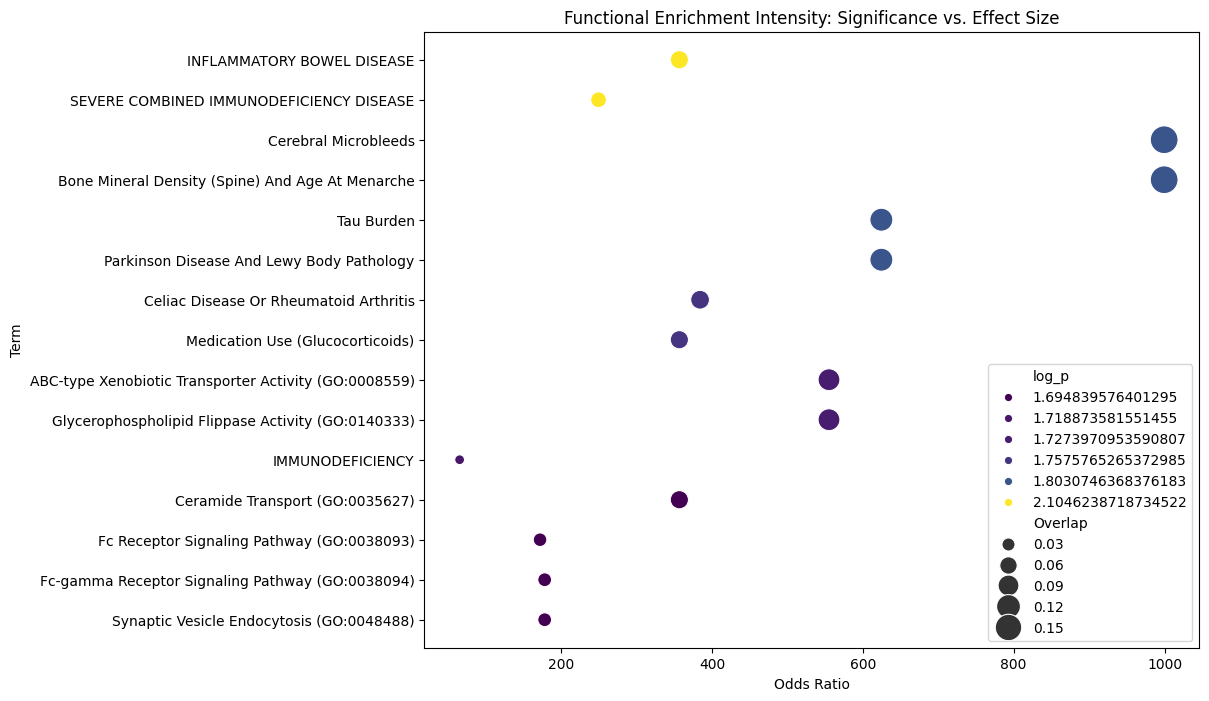

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assume 'df' is your Enrichr results dataframe
# Filter for top 10 terms by Adjusted P-value
top_terms = r.sort_values('Adjusted P-value').head(15)

# Calculate -log10 P-value for color intensity
top_terms['log_p'] = -np.log10(top_terms['Adjusted P-value'])
top_terms['Overlap'] = top_terms['Overlap'].map(lambda x: eval(x))

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=top_terms,
    x="Odds Ratio", 
    y="Term",
    size="Overlap", 
    hue="log_p",
    sizes=(50, 400),
    palette="viridis"
)
plt.title("Functional Enrichment Intensity: Significance vs. Effect Size")
plt.show()

In [14]:
top_terms.head(15)

,Unnamed: 0,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,log_p
0,0,ClinVar_2025,INFLAMMATORY BOWEL DISEASE,0.066667,0.003745,0.007859,0,0,356.803571,1993.609467,ABCB1,2.104624
1,1,ClinVar_2025,SEVERE COMBINED IMMUNODEFICIENCY DISEASE,0.047619,0.005239,0.007859,0,0,249.687500,1311.244059,CD247,2.104624
3,3,GWAS_Catalog_2025,Cerebral Microbleeds,0.166667,0.001499,0.015737,0,0,999.500000,6499.559020,ABCB1,1.803075
4,4,GWAS_Catalog_2025,Bone Mineral Density (Spine) And Age At Menarche,0.166667,0.001499,0.015737,0,0,999.500000,6499.559020,ABCB1,1.803075
5,5,GWAS_Catalog_2025,Tau Burden,0.111111,0.002248,0.015737,0,0,624.593750,3808.549663,MX2,1.803075
6,6,GWAS_Catalog_2025,Parkinson Disease And Lewy Body Pathology,0.111111,0.002248,0.015737,0,0,624.593750,3808.549663,MX2,1.803075
7,7,GWAS_Catalog_2025,Celiac Disease Or Rheumatoid Arthritis,0.071429,0.003495,0.017475,0,0,384.269231,2173.545039,CD247,1.757577
8,8,GWAS_Catalog_2025,Medication Use (Glucocorticoids),0.066667,0.003745,0.017475,0,0,356.803571,1993.609467,CD247,1.757577
49,65,GO_Molecular_Function_2025,ABC-type Xenobiotic Transporter Activity (GO:0...,0.100000,0.002498,0.018733,0,0,555.166667,3326.770642,ABCB1,1.727397
48,64,GO_Molecular_Function_2025,Glycerophospholipid Flippase Activity (GO:0140...,0.100000,0.002498,0.018733,0,0,555.166667,3326.770642,ABCB1,1.727397


In [15]:
keywords = {
    'lupus': 10,       # Direct hit
    'autoimmune': 5,   # Strong hit
    't cell': 3,       # Mechanism hit
    'b cell': 3,
    'inflammation': 2,
    'cytokine': 2,
    'response': 1
}

def calculate_relevance(term):
    score = 0
    term_lower = str(term).lower()
    for word, points in keywords.items():
        if word in term_lower:
            score += points
    return score

# Apply to your dataframe
r['Relevance_Score'] = r['Term'].apply(calculate_relevance)

# Now show the "Most Relevant" terms, even if they aren't the lowest p-value
display(r.sort_values('Relevance_Score', ascending=False).head(10))

,Unnamed: 0,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Relevance_Score
16,16,GWAS_Catalog_2025,Autoimmune Thyroid Disease,1/73,0.018119,0.036238,0,0,69.177083,277.455364,CD247,5
40,47,GO_Biological_Process_2025,T Cell Receptor Signaling Pathway (GO:0050852),1/88,0.021809,0.034638,0,0,57.206897,218.840459,CD247,3
47,58,GO_Cellular_Component_2025,T Cell Receptor Complex (GO:0042101),1/15,0.003745,0.022468,0,0,356.803571,1993.609467,CD247,3
27,34,GO_Biological_Process_2025,Alpha-Beta T Cell Activation (GO:0046631),1/19,0.004741,0.020191,0,0,277.458333,1484.797350,CD247,3
42,49,GO_Biological_Process_2025,T Cell Activation (GO:0042110),1/114,0.028180,0.037281,0,0,43.986726,156.995603,CD247,3
45,52,GO_Biological_Process_2025,Response to Cytokine (GO:0034097),1/123,0.030377,0.037281,0,0,40.723361,142.290378,MX2,3
28,35,GO_Biological_Process_2025,Response to Interferon-Alpha (GO:0035455),1/19,0.004741,0.020191,0,0,277.458333,1484.797350,MX2,1
195,251,DisGeNET,Behavior Disorders,1/44,0.010953,0.040869,0,0,116.000000,523.643758,ABCB1,0
207,263,DisGeNET,Opiate Addiction,1/50,0.012439,0.043090,0,0,101.765306,446.437935,ABCB1,0
206,262,DisGeNET,cardiac event,1/49,0.012191,0.043090,0,0,103.890625,457.850064,ABCB1,0


In [ ]:
r.sort_values(by='Relevance_Score', ascending=False).head(7).to_csv("./data/semantic_analysis.csv")

(0.0, 275.0)

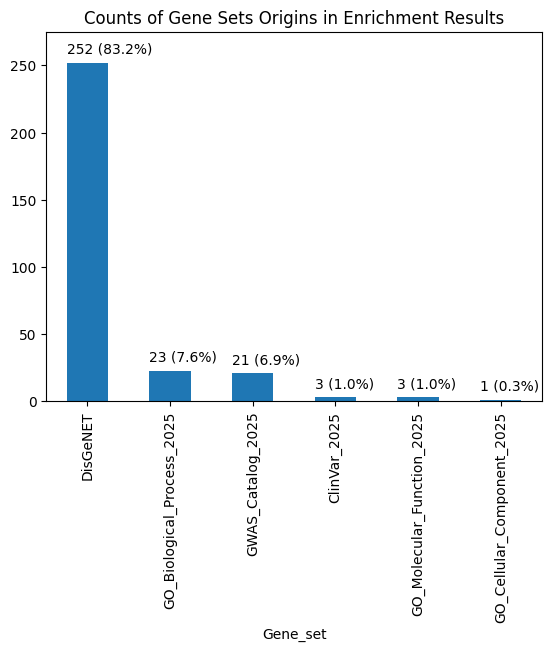

In [ ]:
fig, ax = plt.subplots()
r['Gene_set'].value_counts().plot(kind='bar', ax=ax, title='Counts of Gene Sets Origins in Enrichment Results')
val_counts = r['Gene_set'].value_counts().values
val_prop = val_counts / val_counts.sum()
for patch, count_val, proportion_val in zip(ax.patches, val_counts, val_prop):
    x_pos = patch.get_x()
    y_pos = patch.get_y() + patch.get_height() + 5
    
    annotation_text = f'{int(count_val)} ({proportion_val:.1%})'
    
    ax.annotate(annotation_text, 
                (x_pos, y_pos), 
                xytext=(0, 5), 
                textcoords='offset points', 
                ha='left', va='center')
ax.set_ylim(0, 275)

In [1]:
import Bio

In [3]:
import pandas as pd

In [4]:
pd.__version__

'2.2.3'

In [2]:
print(Bio.__version__)

1.85


# dbSNP Search

In [ ]:
from Bio import Entrez
import pandas as pd
import time
import re # Import regular expressions to parse the DOCSUM field
import traceback
from tqdm import tqdm

# --- IMPORTANT: Always tell NCBI who you are ---
# Please replace this with your actual email
Entrez.email = "adam.e.stogsdill@uth.tmc.edu"
Entrez.tool = "MySNPStatsScript"

'''gene_name = "ABCB1"
organism = "Homo sapiens"'''

def get_dbSNP_data(gene_name: str, organism: str = 'Homo sapiens') -> pd.DataFrame:
    try:
        search_term = f"({gene_name}[Gene Name]) AND {organism}[Organism]"
        handle = Entrez.esearch(db="gene", term=search_term)
        record = Entrez.read(handle)
        handle.close()

        if not record["IdList"]:
            print(f"Error: Could not find Gene ID for {gene_name}.")
            exit()

        gene_id = record["IdList"][0]
        print(f"Found Gene ID: {gene_id}\n")
        time.sleep(0.5) # NCBI's 3-requests-per-second limit

        print(f"--- 2. Linking Gene ID {gene_id} to dbSNP ---")
        handle = Entrez.elink(dbfrom="gene", db="snp", id=gene_id, linkname="gene_snp")
        record = Entrez.read(handle)
        handle.close()

        if not record[0]["LinkSetDb"]:
            print(f"Error: No SNPs found linked to Gene ID {gene_id}.")
            exit()

        snp_ids = [link["Id"] for link in record[0]["LinkSetDb"][0]["Link"]]
        print(f"Found {len(snp_ids)} linked SNPs. Fetching details for first 20...")
        time.sleep(0.5)

        handle = Entrez.esummary(db="snp", id=",".join(snp_ids))
        record = Entrez.read(handle)
        handle.close()

        # --- 4. Process Results into a DataFrame (NEW, CORRECTED LOGIC) ---
        snp_data = []

        # Helper regex to find alleles like 'SEQ=[C/T]' in the DOCSUM field
        allele_regex = re.compile(r"SEQ=\[([^\]]+)\]")

        # Access the LIST of DocumentSummary objects
        doc_summaries = record['DocumentSummarySet']['DocumentSummary']
        for data in tqdm(doc_summaries):

            # Get RSID (using the key from your example)
            rsid = 'rs' + data['SNP_ID']

            # Get Chromosome and Position
            if data['CHRPOS'] != "":
                chrom = data['CHRPOS'].split(':')[0]
                pos = data['CHRPOS'].split(':')[1]
            else:
                chrom = None
                pos = None


            # Get Alleles by parsing the 'DOCSUM' string
            alleles = 'N/A'
            docsum_match = allele_regex.search(data['DOCSUM'])
            if docsum_match:
                alleles = docsum_match.group(1) # Get the part inside the brackets

            # Get Clinical Significance
            clinical_sig = data.get('CLINICAL_SIGNIFICANCE', 'N/A')
            if not clinical_sig: # Handle empty strings
                clinical_sig = 'N/A'

            # Get all associated genes (since there can be more than one)
            gene_list = [gene['NAME'] for gene in data['GENES']]
            genes_str = ",".join(gene_list)

            snp_data.append({
                'RSID': rsid,
                'AssociatedGenes': genes_str,
                'Chromosome': chrom if chrom is not None else 'N/A',
                'Position': int(pos) if pos is not None else None,
                'Alleles': alleles,
                'ClinicalSignificance': clinical_sig,
                'SNP_Class': data['SNP_CLASS']
            })

        snp_df = pd.DataFrame(snp_data)
        snp_df = snp_df.drop_duplicates(subset=['RSID'])
        snp_df = snp_df.dropna()
        return snp_df

    except Exception as e:
        print(f"\nAn error occurred: {e}")
        print(traceback.format_exc())
        print("This could be due to your email not being set, or an NCBI API issue.")

In [37]:
dbSNP_data = {}
for gene in ['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2']:
    dbSNP_data[gene] = get_dbSNP_data(gene_name=gene)

Found Gene ID: 5243

--- 2. Linking Gene ID 5243 to dbSNP ---
Found 46217 linked SNPs. Fetching details for first 20...
--- 3. Fetching SNP details (E-Summary) ---


100%|██████████| 9999/9999 [00:00<00:00, 427397.89it/s]


Found Gene ID: 919

--- 2. Linking Gene ID 919 to dbSNP ---
Found 20249 linked SNPs. Fetching details for first 20...
--- 3. Fetching SNP details (E-Summary) ---


100%|██████████| 9999/9999 [00:00<00:00, 593942.10it/s]


Found Gene ID: 1827

--- 2. Linking Gene ID 1827 to dbSNP ---
Found 21477 linked SNPs. Fetching details for first 20...
--- 3. Fetching SNP details (E-Summary) ---


100%|██████████| 9999/9999 [00:00<00:00, 366063.93it/s]


Found Gene ID: 3802

--- 2. Linking Gene ID 3802 to dbSNP ---
Found 8124 linked SNPs. Fetching details for first 20...
--- 3. Fetching SNP details (E-Summary) ---


100%|██████████| 8124/8124 [00:00<00:00, 283018.06it/s]


Found Gene ID: 4600

--- 2. Linking Gene ID 4600 to dbSNP ---
Found 11738 linked SNPs. Fetching details for first 20...
--- 3. Fetching SNP details (E-Summary) ---


100%|██████████| 9999/9999 [00:00<00:00, 469966.22it/s]


In [38]:
for gene in ['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2']:
    dbSNP_data[gene].to_csv(f'./data/{gene}_dbSNP_data.csv', index=False)

## Macro-Descriptive Analysis on dbSNP data

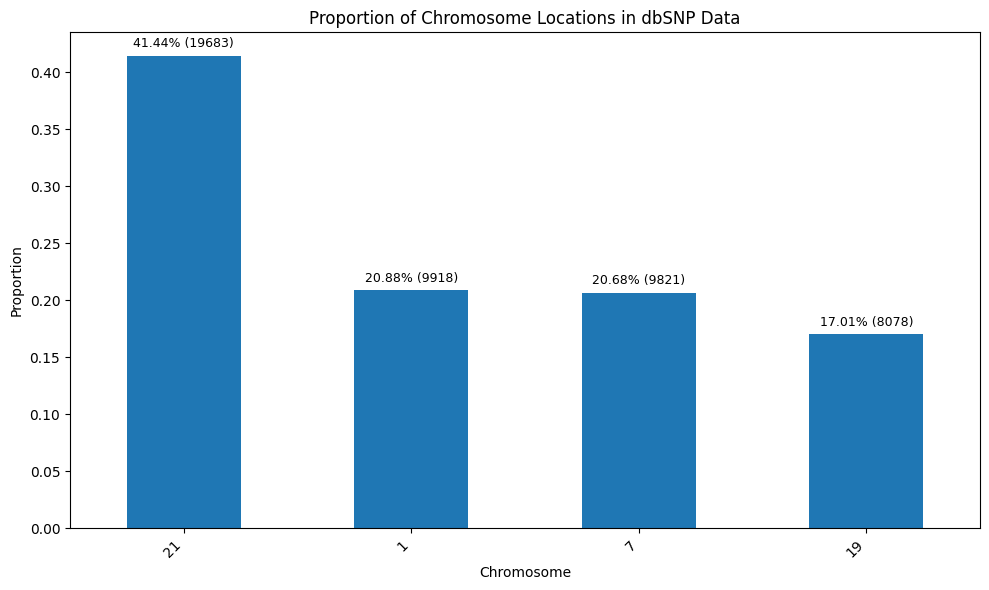

In [12]:
import pandas as pd
parent_gene = []
dbSNP_data = {}

for gene in ['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2']:
    dbSNP_data[gene] = pd.read_csv(f'./data/{gene}_dbSNP_data.csv')

for gene in ['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2']:
    parent_gene.extend([gene] * len(dbSNP_data[gene]))

macro_descriptive_data = pd.concat([dbSNP_data[gene] for gene in ['ABCB1', 'CD247', 'DSC1', 'KIR2DL3', 'MX2']])
macro_descriptive_data['parent_gene'] = parent_gene
macro_descriptive_data.to_csv('./data/macro_descriptive_data.csv', index=False)

# weird Chromosome value found and removed
macro_descriptive_data = macro_descriptive_data[macro_descriptive_data['Chromosome'] != 'NT_187644.1']

# x axis is proportion of total SNPs and counts are display over the bar
import matplotlib.pyplot as plt

chromosome_counts = macro_descriptive_data['Chromosome'].value_counts()
chromosome_proportions = macro_descriptive_data['Chromosome'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 6))
chromosome_proportions.plot(kind='bar', ax=ax, title='Proportion of Chromosome Locations in dbSNP Data', ylabel='Proportion')

for i, proportion in enumerate(chromosome_proportions):
    count = chromosome_counts.iloc[i]
    proportion = chromosome_proportions.iloc[i]
    ax.text(i, proportion + 0.005, f'{proportion:.2%} ({count})', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


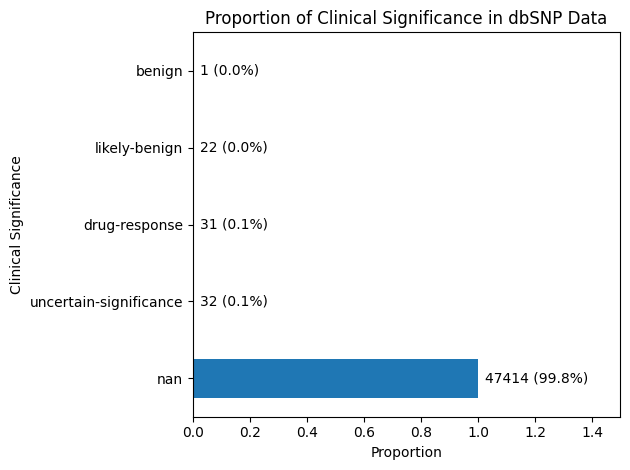

In [10]:
import matplotlib.pyplot as plt

counts = macro_descriptive_data['ClinicalSignificance'].value_counts(dropna=False)
total_count = counts.sum()
proportions = counts / total_count

fig, ax = plt.subplots()

proportions.plot(kind='barh', ax=ax, title='Proportion of Clinical Significance in dbSNP Data')

for i, patch in enumerate(ax.patches):
    category = counts.index[i]
    count_val = counts.loc[category]
    proportion_val = proportions.loc[category]
    
    x_pos = patch.get_width()
    y_pos = patch.get_y() + patch.get_height() / 2
    
    annotation_text = f'{int(count_val)} ({proportion_val:.1%})'
    
    ax.annotate(annotation_text, 
                (x_pos, y_pos), 
                xytext=(5, 0), 
                textcoords='offset points', 
                ha='left', va='center')

ax.set_xlim(0, max(proportions) * 1.5) # Adjust x-axis limit to accommodate annotations
ax.set_xlabel('Proportion')
ax.set_ylabel('Clinical Significance')
plt.tight_layout()

Text(0.5, 0, 'Proportion')

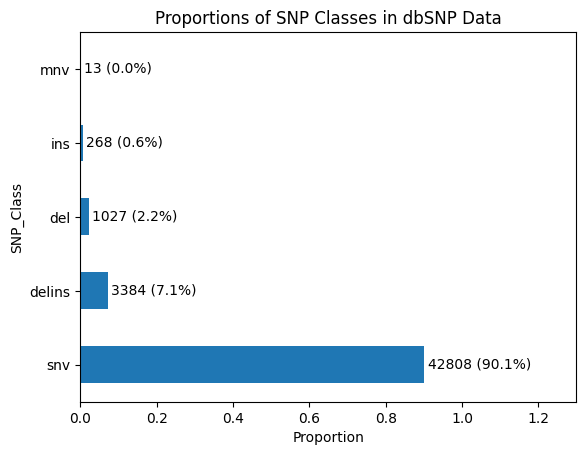

In [15]:
counts = macro_descriptive_data['SNP_Class'].value_counts()
proportions = counts / counts.sum()

ax = proportions.plot(kind='barh', title='Proportions of SNP Classes in dbSNP Data')
for i, patch in enumerate(ax.patches):
    count = counts.iloc[i]
    proportion_val = proportions.iloc[i]
    ax.annotate(f'{count} ({proportion_val:.1%})', (patch.get_width() + 0.01, patch.get_y() + 0.2))

ax.set(xlim=(0, 1.3))
ax.set_xlabel('Proportion')

Text(0.5, 0, 'Proportion')

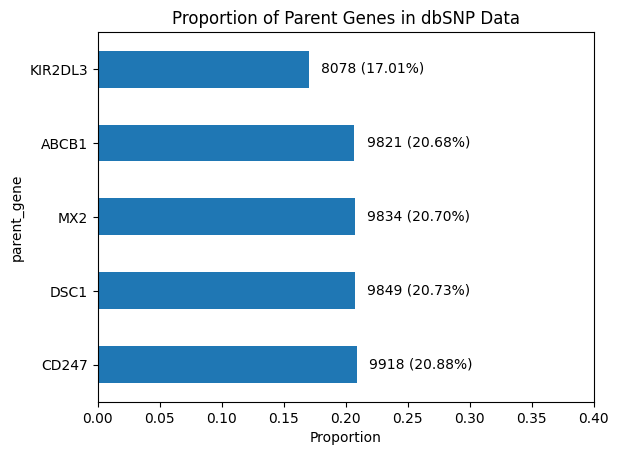

In [17]:
counts = macro_descriptive_data['parent_gene'].value_counts()
proportions = counts / counts.sum()

ax = proportions.plot(kind='barh', title='Proportion of Parent Genes in dbSNP Data')

for i, patch in enumerate(ax.patches):
    proportion = patch.get_width()
    count = counts.iloc[i]
    ax.annotate(f'{count} ({proportion:.2%})', (proportion + 0.01, patch.get_y() + 0.2))

ax.set(xlim=(0, .4))
ax.set_xlabel('Proportion')

## Each gene plot 

In [23]:
import matplotlib.pyplot as plt
def generate_gene_plot(gene_name: str):
    gene_data = macro_descriptive_data[macro_descriptive_data['parent_gene'] == gene_name]

    # filter for associated genes
    remove_gene_rows = []
    for i, row in gene_data.iterrows():
        if row['AssociatedGenes'] != gene_name:
            remove_gene_rows.append(i)
    gene_data = gene_data.drop(remove_gene_rows)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
    
    ax_1 = gene_data['ClinicalSignificance'].value_counts().plot(kind='barh', title=f'Counts of Clinical Significance for {gene_name} in dbSNP Data', ax=ax1)
    for patch in ax_1.patches:
        ax_1.annotate(str(patch.get_width()), (patch.get_width() + 1000, patch.get_y() + 0.2))
        
    ax_2 = gene_data['SNP_Class'].value_counts().plot(kind='barh', title=f'Counts of SNP Classes for {gene_name} in dbSNP Data', ax=ax2)
    for patch in ax_2.patches:
        ax_2.annotate(str(patch.get_width()), (patch.get_width() + 1000, patch.get_y() + 0.2))
        
    ax_3 = gene_data['Position'].plot(kind='hist', title=f'Counts of Parent Genes for {gene_name} in dbSNP Data', ax=ax3, bins=1000)

    
        
    ax_1.set(xlim=(0, 15000))
    ax_2.set(xlim=(0, 55000))
    #plt.tight_layout()
    plt.show()

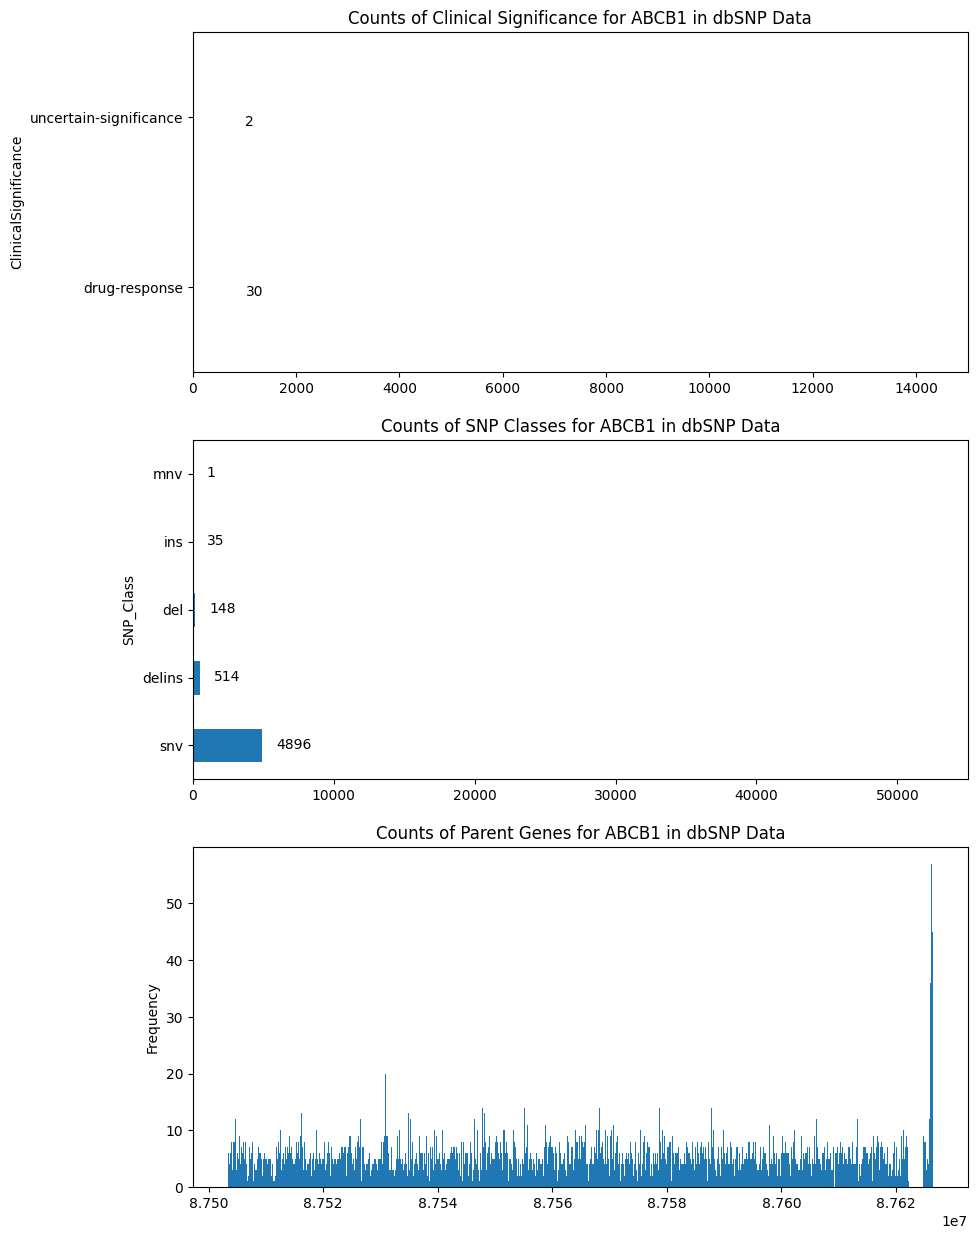

In [24]:
generate_gene_plot('ABCB1')

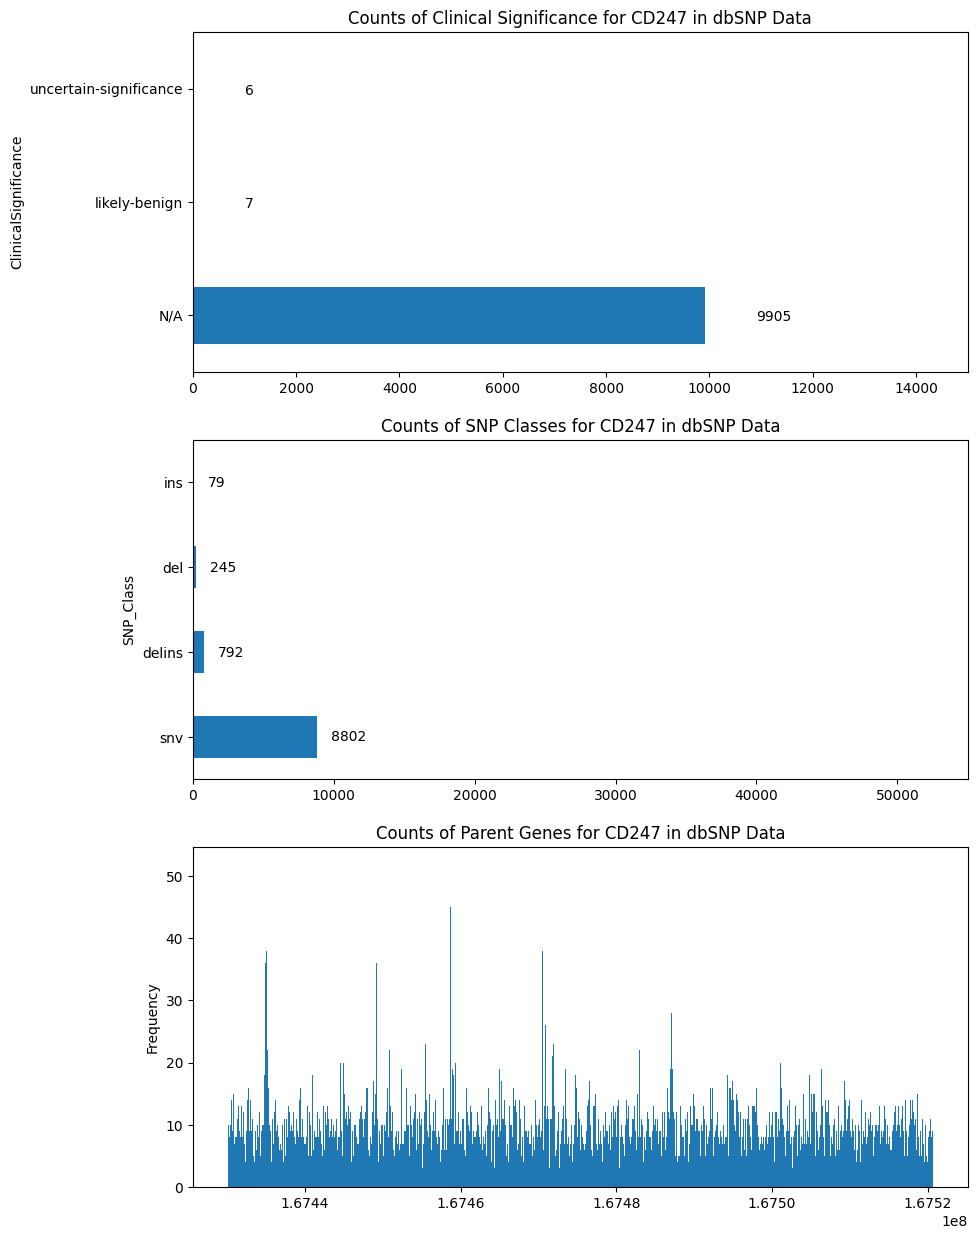

In [107]:
generate_gene_plot('CD247')

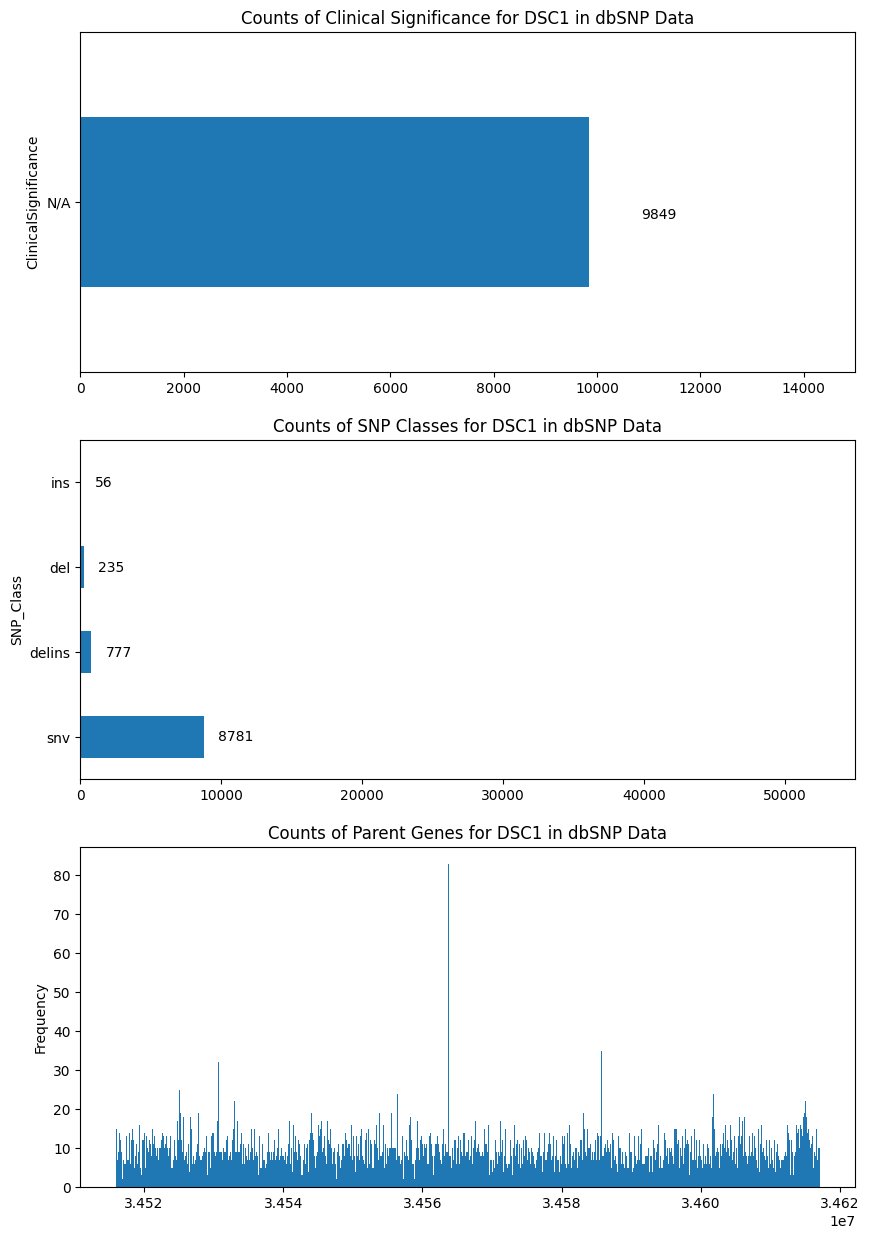

In [108]:
generate_gene_plot('DSC1')

IndexError: index 0 is out of bounds for axis 0 with size 0

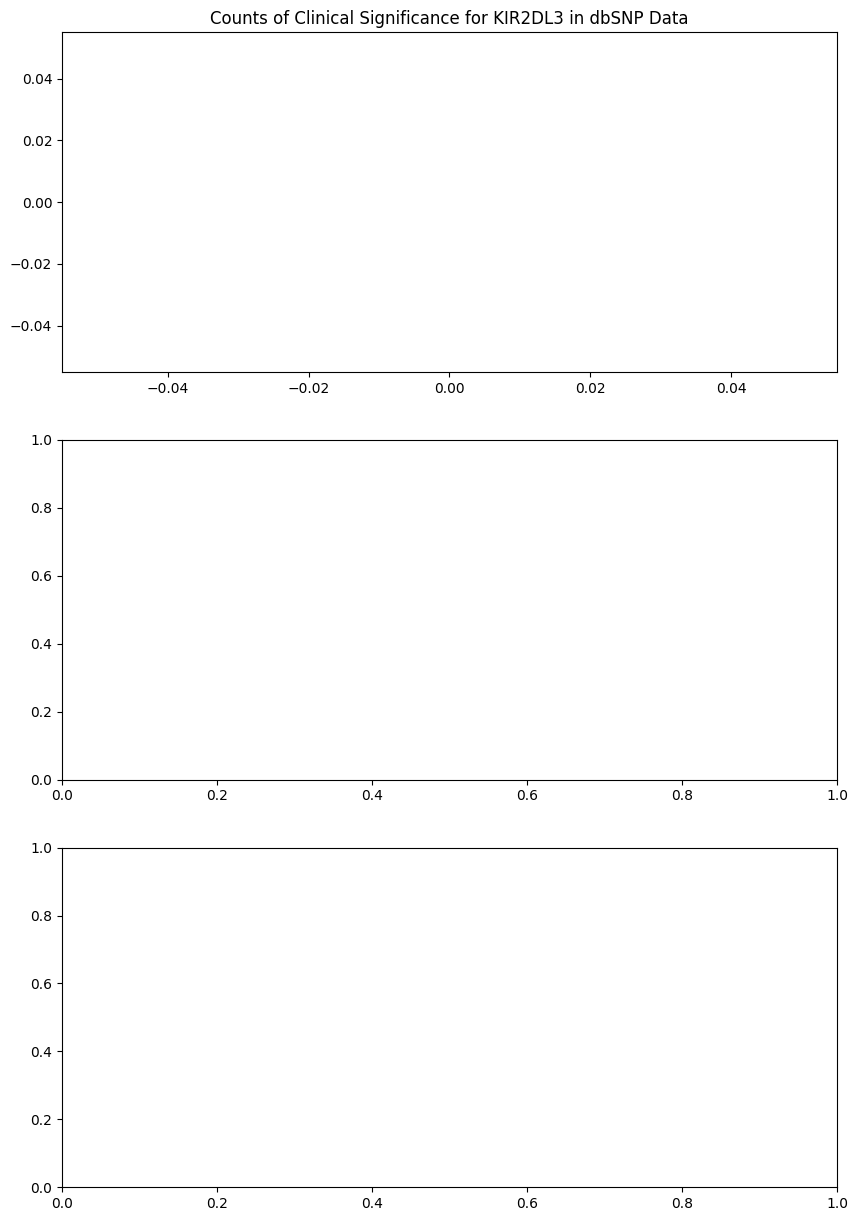

In [28]:
generate_gene_plot('KIR2DL3')

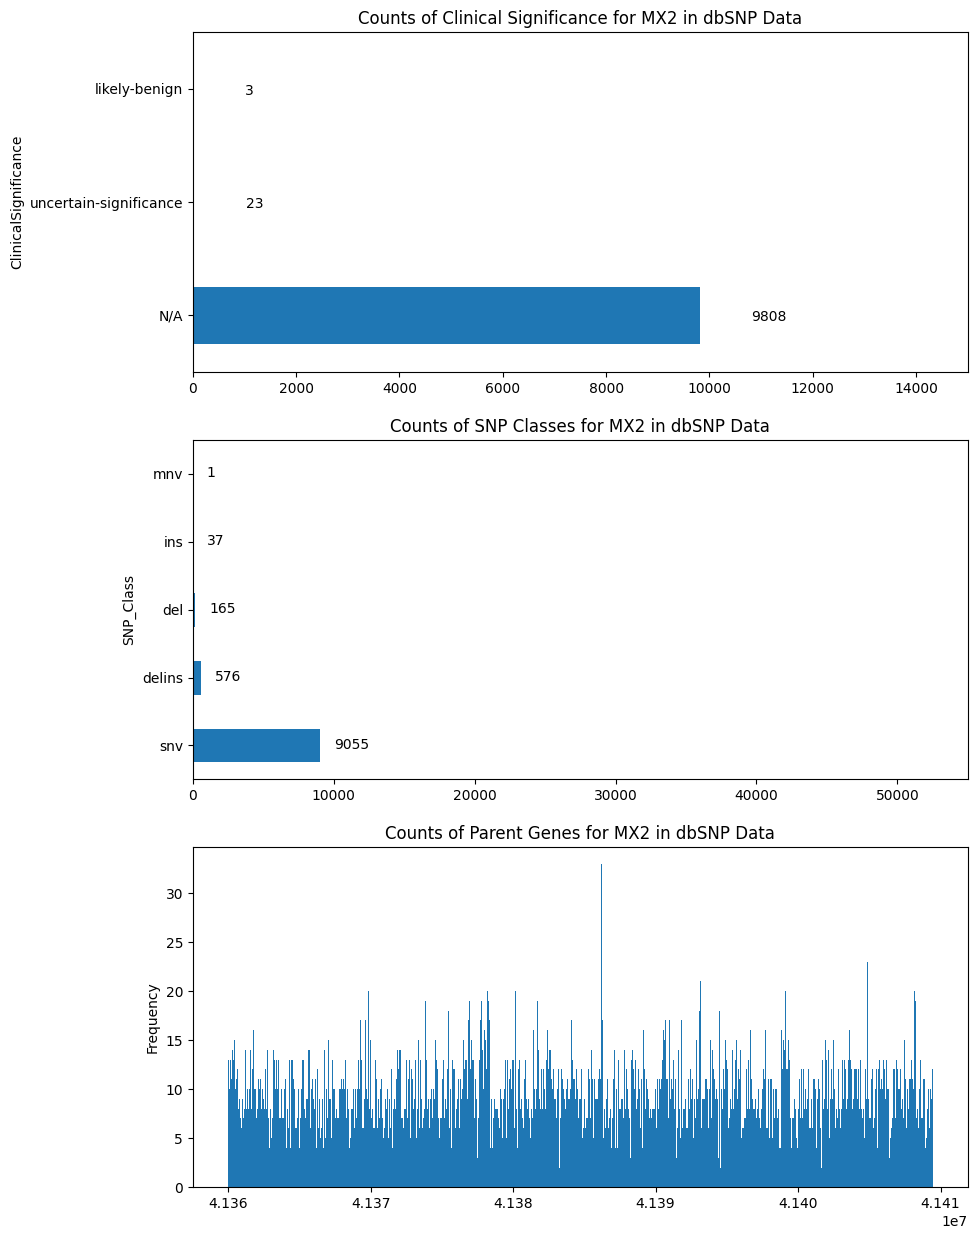

In [110]:
generate_gene_plot('MX2')

In [30]:
gene_data = macro_descriptive_data[macro_descriptive_data['parent_gene'] == 'KIR2DL3'].sort_values(by='Position', ascending=False)
gene_data

,RSID,AssociatedGenes,Chromosome,Position,Alleles,ClinicalSignificance,SNP_Class,parent_gene
1947,rs1365593949,"KIR2DS4,KIR3DL2",19,54849060.0,G/A,NaN,snv,KIR2DL3
1602,rs1387861351,"KIR2DS4,KIR3DL2",19,54849059.0,T/C,NaN,snv,KIR2DL3
5997,rs866119456,"KIR2DS4,KIR3DL2",19,54849058.0,G/A/C,NaN,snv,KIR2DL3
2654,rs1325184144,"KIR2DS4,KIR3DL2",19,54849057.0,GT/-,NaN,delins,KIR2DL3
4211,rs1227215150,"KIR2DS4,KIR3DL2",19,54849049.0,G/A/C/T,NaN,snv,KIR2DL3
...,...,...,...,...,...,...,...,...
6672,rs562276792,NaN,19,54767216.0,C/A/G/T,NaN,snv,KIR2DL3
4079,rs1234996058,NaN,19,54767214.0,C/A,NaN,snv,KIR2DL3
155,rs1481136930,NaN,19,54767210.0,G/A,NaN,snv,KIR2DL3
5008,rs1178388518,NaN,19,54767209.0,A/G,NaN,snv,KIR2DL3


In [36]:
gene_data = macro_descriptive_data[macro_descriptive_data['parent_gene'] == 'KIR2DL3'].sort_values(by='Position', ascending=False)
remove_gene_rows = []
for i, row in gene_data.iterrows():
    if row['AssociatedGenes'] != 'KIR2DL3':
        if not pd.isna(row['AssociatedGenes']):
            remove_gene_rows.extend(row['AssociatedGenes'].split(','))

remove_gene_rows = list(set(remove_gene_rows))
remove_gene_rows

['KIR2DL1', 'LOC101928804', 'KIR2DS4', 'KIR3DL2']